# Neural Network with Consolidated Categories

In [1]:
# %pip install pandas matplotlib seaborn scikit-learn tensorflow

In [2]:
import pandas as pd

data = pd.read_csv('/workspaces/group-project-bas-team/data/cleaned_data_with_parent.csv')

In [3]:
data['parent_category'].value_counts(normalize=True)*100

parent_category
7     17.598996
6     15.780189
12    11.017921
1      7.691083
10     7.296244
8      6.956173
3      6.176047
0      4.735522
5      4.692853
13     4.196757
14     3.827392
9      3.293722
4      2.565180
11     2.101563
2      2.070358
Name: proportion, dtype: float64

In [4]:
data_unencoded = pd.read_csv('/workspaces/group-project-bas-team/data/data_unencoded.csv')

data[['Survey ResponseID', 'Order Date']] = data_unencoded[['Survey ResponseID', 'Order Date']]

data['Order Date'] = pd.to_datetime(data['Order Date'])
data = data.sort_values(by=['Survey ResponseID', 'Order Date'])
data['Purchase_Order'] = data.groupby('Survey ResponseID')['Order Date'].rank(method='first').astype(int)

data['Days_Since_Last_Purchase'] = data.groupby('Survey ResponseID')['Order Date'].diff().dt.days.fillna(0)

data = data.drop(columns=['Order Date'])

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
data['Survey ResponseID'] = encoder.fit_transform(data['Survey ResponseID'])

from sklearn.preprocessing import StandardScaler

train = data[data['order_year']<=2021]
test = data[data['order_year']>2021]

train_cats = set(train['Category'].unique())
test_cats = set(test['Category'].unique())
unseen = test_cats - train_cats
if len(unseen) > 0:
    test = test[~test['Category'].isin(unseen)]


data_limited_train = train.drop(['Title', 'ASIN/ISBN (Product Code)', 'Category'], axis=1)
data_limited_test = test.drop(['Title', 'ASIN/ISBN (Product Code)', 'Category'], axis=1)

X_train = data_limited_train.drop('parent_category', axis=1)
y_train = data_limited_train['parent_category']
X_train_scaled = StandardScaler().fit_transform(X_train)

X_test = data_limited_test.drop('parent_category', axis=1)
y_test = data_limited_test['parent_category']
X_test_scaled = StandardScaler().fit_transform(X_test)

X_train = X_train.drop(X_train.filter(regex='^Shipping Address').columns, axis=1)
X_test = X_test.drop(X_test.filter(regex='^Shipping Address').columns, axis=1)

X_train = X_train.drop(columns = ['diabetes_No', 'wheelchair_No', 'marijuana_No', 'sexual-orientation_heterosexual (straight)', 
                                  'gender_Female', 'alcohol_No'])
X_test = X_test.drop(columns = ['diabetes_No', 'wheelchair_No', 'marijuana_No', 'sexual-orientation_heterosexual (straight)', 
                                  'gender_Female', 'alcohol_No'])

X_train_scaled = StandardScaler().fit_transform(X_train)
X_test_scaled = StandardScaler().fit_transform(X_test) 

/tmp/ipykernel_31227/1929692612.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[['Survey ResponseID', 'Order Date']] = data_unencoded[['Survey ResponseID', 'Order Date']]
/tmp/ipykernel_31227/1929692612.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['Purchase_Order'] = data.groupby('Survey ResponseID')['Order Date'].rank(method='first').astype(int)
/tmp/ipykernel_31227/1929692612.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which ha

In [5]:
X_train.shape

(113655, 102)

In [6]:
import tensorflow as tf

tf.keras.backend.clear_session()
tf.random.set_seed(42)

model = tf.keras.Sequential()

model.add(tf.keras.layers.InputLayer(input_shape=(102, )))

model.add(tf.keras.layers.Dense(300, activation="relu")) 

model.add(tf.keras.layers.Dense(100, activation="relu"))

model.add(tf.keras.layers.Dense(15, activation="softmax")) 

I0000 00:00:1777945917.517697   31227 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777945921.302700   31227 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777945927.208553   31227 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
E0000 00:00:1777945929.940952   31227 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 300)            │        30,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │         1,515 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,515 (244.20 KB)

 Trainable params: 62,515 (244.20 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy", tf.keras.metrics.F1Score(average="weighted")]) # weighted accounts for class imbalance

In [9]:
history = model.fit(X_train_scaled, y_train, epochs=30, shuffle=False)

Epoch 1/30


W0000 00:00:1777945930.706755   31227 cpu_allocator_impl.cc:82] Allocation of 46371240 exceeds 10% of free system memory.


3552/3552 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.2351 - f1_score: 0.1284 - loss: 2.3921
Epoch 2/30
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.2614 - f1_score: 0.1288 - loss: 2.3073
Epoch 3/30
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.2734 - f1_score: 0.1292 - loss: 2.2649
Epoch 4/30
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.2820 - f1_score: 0.1294 - loss: 2.2342
Epoch 5/30
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.2884 - f1_score: 0.1295 - loss: 2.2118
Epoch 6/30
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.2942 - f1_score: 0.1296 - loss: 2.1937
Epoch 7/30
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.2993 - f1_score: 0.1297 - loss: 2.1780
Epoch 8/30
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.3037 - f1_score: 0.1297 - loss: 2.1643
Epoch 9/30
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.3064 - f1_score: 0.1298 - loss: 2.1528
Epoch 10/30
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 6s 

In [10]:
test_loss, test_acc, test_f1 = model.evaluate(X_test_scaled, y_test, verbose=2)
print('\nTest Accuracy:', test_acc)
print('\nTest F1-score:', test_f1)

W0000 00:00:1777946139.053921   31227 cpu_allocator_impl.cc:82] Allocation of 17678232 exceeds 10% of free system memory.


1355/1355 - 2s - 1ms/step - accuracy: 0.2742 - f1_score: 0.1305 - loss: 2.2915

Test Accuracy: 0.2742043435573578

Test F1-score: 0.13047492504119873


Predicting the consolidated categories has improved our accuracy greatly to 27.64%

1355/1355 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


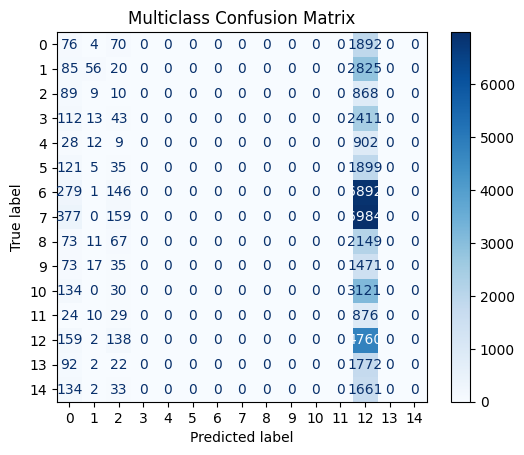

In [11]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1) if len(y_test.shape) > 1 else y_test

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap=plt.cm.Blues)
plt.title("Multiclass Confusion Matrix")
plt.show()

However, it seems our model is primarily predicting only two classes

In [12]:
%pip install imblearn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [19]:
# resampling training data
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train_scaled, y_train)

In [23]:
import tensorflow as tf

tf.keras.backend.clear_session()
tf.random.set_seed(42)

model = tf.keras.Sequential()

model.add(tf.keras.layers.InputLayer(input_shape=(102, )))

model.add(tf.keras.layers.Dense(300, activation="relu")) 

model.add(tf.keras.layers.Dense(100, activation="relu"))

model.add(tf.keras.layers.Dense(15, activation="softmax")) 

In [24]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy", tf.keras.metrics.F1Score(average="weighted")])

In [ ]:
history = model.fit(X_train_resampled, y_train_resampled, epochs=30, shuffle=False, verbose=2)

Epoch 1/30
9428/9428 - 18s - 2ms/step - accuracy: 0.6896 - f1_score: 0.1319 - loss: 1.0163
Epoch 2/30
9428/9428 - 17s - 2ms/step - accuracy: 0.7009 - f1_score: 0.1319 - loss: 0.9694
Epoch 3/30
9428/9428 - 22s - 2ms/step - accuracy: 0.7062 - f1_score: 0.1319 - loss: 0.9470
Epoch 4/30
9428/9428 - 37s - 4ms/step - accuracy: 0.7098 - f1_score: 0.1319 - loss: 0.9334
Epoch 5/30
9428/9428 - 21s - 2ms/step - accuracy: 0.7123 - f1_score: 0.1320 - loss: 0.9263
Epoch 6/30
9428/9428 - 25s - 3ms/step - accuracy: 0.7152 - f1_score: 0.1320 - loss: 0.9169
Epoch 7/30
9428/9428 - 19s - 2ms/step - accuracy: 0.7170 - f1_score: 0.1320 - loss: 0.9121
Epoch 8/30
9428/9428 - 19s - 2ms/step - accuracy: 0.7180 - f1_score: 0.1320 - loss: 0.9105
Epoch 9/30
9428/9428 - 18s - 2ms/step - accuracy: 0.7188 - f1_score: 0.1320 - loss: 0.9082
Epoch 10/30
9428/9428 - 19s - 2ms/step - accuracy: 0.7205 - f1_score: 0.1320 - loss: 0.9026
Epoch 11/30
9428/9428 - 18s - 2ms/step - accuracy: 0.7216 - f1_score: 0.1320 - loss: 0.90

In [ ]:
test_loss, test_acc, test_f1 = model.evaluate(X_test_scaled, y_test, verbose=2)
print('\nTest Accuracy:', test_acc)
print('\nTest F1-score:', test_f1)

W0000 00:00:1777946690.720977   31227 cpu_allocator_impl.cc:82] Allocation of 17678232 exceeds 10% of free system memory.


1355/1355 - 2s - 1ms/step - accuracy: 0.0461 - f1_score: 0.1175 - loss: 7.6864

Test Accuracy: 0.04606614634394646

Test F1-score: 0.11751160025596619


 101/1355 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  

W0000 00:00:1777946692.948338   31227 cpu_allocator_impl.cc:82] Allocation of 17678232 exceeds 10% of free system memory.


1355/1355 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


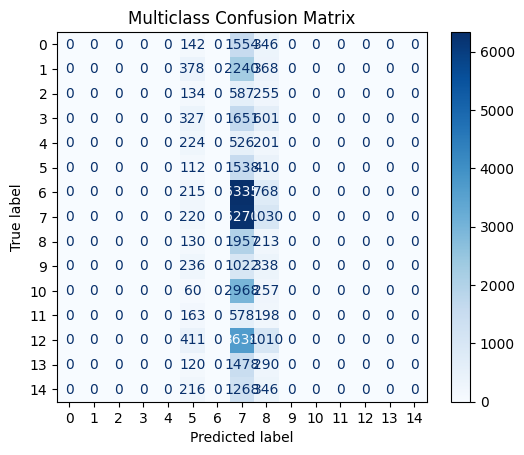

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1) if len(y_test.shape) > 1 else y_test

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap=plt.cm.Blues)
plt.title("Multiclass Confusion Matrix")
plt.show()